### ESC403 Semesterproject ###
This script includes the following steps for the ESC403 Semesterproject:
1. Import Datasets
2. Fuse the two Datasets
3. Create variable names, we can actually work with
4. Cut the two datasets to the correct years (1990-2025)
5. Take care of NA values

# 1. Import Datasets

In [31]:
# import Datasets
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

weather = pd.read_csv("weather_data.csv", sep=";")
pollen = pd.read_csv("pollen_data.csv", sep=";")

print(weather.head())
print(pollen.head())

  station_abbr reference_timestamp  tre200d0  tre200dx  tre200dn  tre005d0  \
0          DAV    01.01.1867 00:00      -7.7       NaN       NaN       NaN   
1          DAV    02.01.1867 00:00     -11.3       NaN       NaN       NaN   
2          DAV    03.01.1867 00:00     -14.7       NaN       NaN       NaN   
3          DAV    04.01.1867 00:00     -20.8       NaN       NaN       NaN   
4          DAV    05.01.1867 00:00     -17.9       NaN       NaN       NaN   

   tre005dx  tre005dn  ure200d0  pva200d0  ...  sremaxdv  erefaod0  xcd000d0  \
0       NaN       NaN       NaN       NaN  ...       NaN       NaN       NaN   
1       NaN       NaN       NaN       NaN  ...       NaN       NaN       NaN   
2       NaN       NaN       NaN       NaN  ...       NaN       NaN       NaN   
3       NaN       NaN       NaN       NaN  ...       NaN       NaN       NaN   
4       NaN       NaN       NaN       NaN  ...       NaN       NaN       NaN   

   dkl010d0  xno000d0  xno012d0  rreetsd0  tso005d

# 2. Date Formating and Cutting

In [32]:
# convert timestamps correctly
weather["reference_timestamp"] = pd.to_datetime(
    weather["reference_timestamp"],
    format="%d.%m.%Y %H:%M"
)

pollen["reference_timestamp"] = pd.to_datetime(
    pollen["reference_timestamp"],
    format="%d.%m.%Y %H:%M"
)

In [33]:
#select years
weather_raw = weather[
    (weather["reference_timestamp"].dt.year >= 1990) &
    (weather["reference_timestamp"].dt.year <= 2025)
]

pollen_raw = pollen[
    (pollen["reference_timestamp"].dt.year >= 1990) &
    (pollen["reference_timestamp"].dt.year <= 2025)
]

# 3. Variable Selction

In [34]:
# List of relevant variables and their simpler names

weather_relevant_variables = [ "reference_timestamp",
                    "tre200d0", "tre200dx", "tre200dn", "tso005d0",
                    "ure200d0",
                    "rka150d0",
                    "fkl010d0",
                    "gre000d0", "sre000d0",
]

weather_translation = [ "reference_timestamp",
            "temp_mean", "temp_max", "temp_min", "soil_temp_5cm",
            "rel_humidity",
            "tot_percipitation",
            "windspeed",
            "glob_radiation", "sunshine_duration",
]

pollen_relevant_variables = [ "reference_timestamp",
                        "kaalnud0", "kabetud0", "kacoryd0", "kafagud0", "kafraxd0", "kaquerd0",
                        "khpoacd0"
]

pollen_translation = [ "reference_timestamp",
                "erle_pollen", "birke_pollen", "hasel_pollen", "buche_pollen", "gemeine_esche_pollen", "eiche_pollen", 
                "graeser_pollen", 
]

In [35]:
#Defining new dataframes for slected columns and setting less complex column names.
#We also set "reference_timestamp as and index"

weather_relevant = weather_raw[weather_relevant_variables].copy()
weather_relevant.columns = weather_translation

weather_relevant = weather_relevant.sort_values("reference_timestamp")
weather_relevant = weather_relevant.set_index("reference_timestamp")

pollen_relevant = pollen_raw[pollen_relevant_variables].copy()
pollen_relevant.columns = pollen_translation

pollen_relevant = pollen_relevant.sort_values("reference_timestamp")
pollen_relevant = pollen_relevant.set_index("reference_timestamp")

print(pollen_relevant.index)

DatetimeIndex(['1990-03-12', '1990-03-13', '1990-03-14', '1990-03-15',
               '1990-03-23', '1990-03-24', '1990-03-25', '1990-03-26',
               '1990-03-27', '1990-03-28',
               ...
               '2025-12-21', '2025-12-22', '2025-12-23', '2025-12-24',
               '2025-12-25', '2025-12-26', '2025-12-27', '2025-12-28',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[us]', name='reference_timestamp', length=7522, freq=None)


# 4. Data Cleaning and Artificial Extension

In [36]:
#Check weather data for NA and Nan and fill accordingly
print(weather_relevant.isna().sum())

temp_mean              0
temp_max               0
temp_min               0
soil_temp_5cm        294
rel_humidity           0
tot_percipitation      0
windspeed              0
glob_radiation         0
sunshine_duration    199
dtype: int64


### 4.1 soil_temp_5cm column

In [37]:
#Fixing soil_temp_5cm column
s = weather_relevant["soil_temp_5cm"].copy()
na_bool = s.isna()
gap = na_bool != na_bool.shift()
print(gap.sum()) #5 gaps mean 2 real gaps (1 is beginning)

5


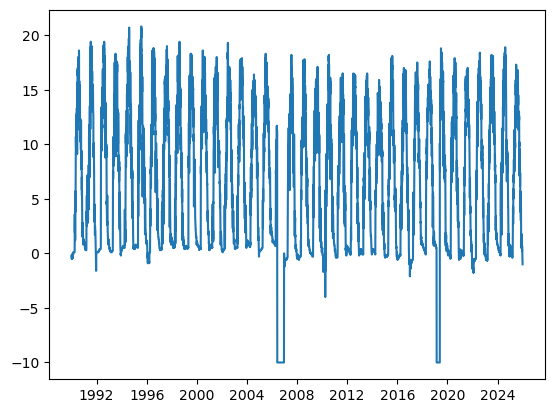

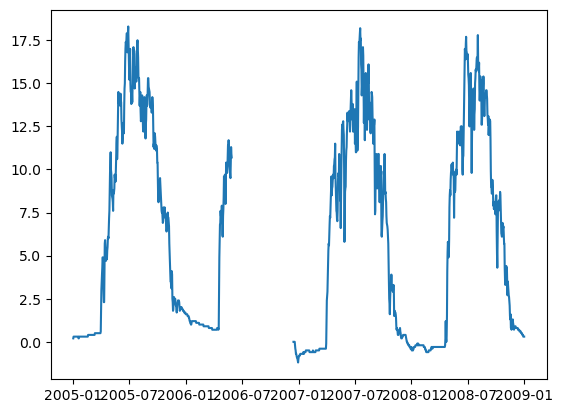

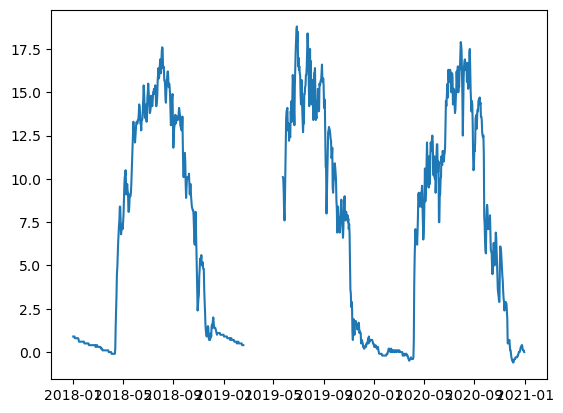

In [38]:
s_filled = s.fillna(-10)
plt.plot(weather_relevant.index, s_filled)
plt.show()

df_plot1 = weather_relevant.loc["2005":"2008"].copy()
df_plot2 = weather_relevant.loc["2018":"2020"].copy()

plt.plot(df_plot1.index, df_plot1["soil_temp_5cm"])
plt.show()
plt.plot(df_plot2.index, df_plot2["soil_temp_5cm"])
plt.show()

# Here we will fill the gaps yousing year-day averages over all the years

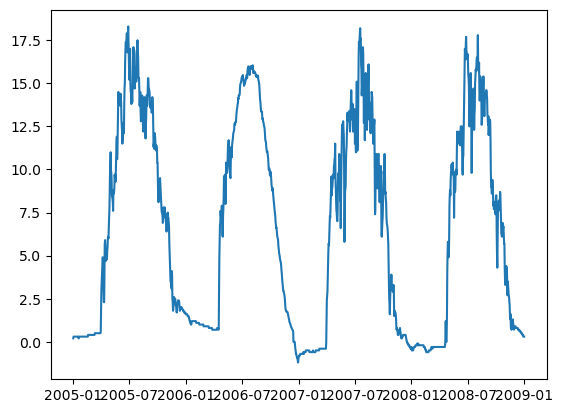

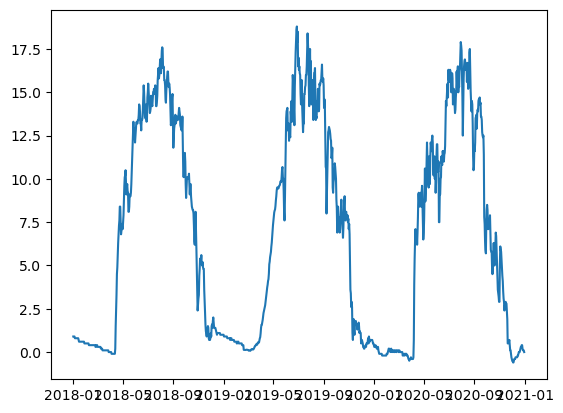

In [39]:
# Fill missing data with avergages of all years since we do not want to model or describe local short term
# events but rather long term behaviour

soil_temp_copy = weather_relevant["soil_temp_5cm"].copy()
doy = soil_temp_copy.index.dayofyear
clim = soil_temp_copy.groupby(doy).mean()
soil_temp_filled = soil_temp_copy.copy()
mask = soil_temp_copy.isna()
soil_temp_filled[mask] = doy[mask].map(clim)

weather_relevant_extended = weather_relevant.copy()
weather_relevant_extended["soil_temp_5cm"] = soil_temp_filled

df_plot1 = weather_relevant_extended.loc["2005":"2008"].copy()
df_plot2 = weather_relevant_extended.loc["2018":"2020"].copy()

plt.plot(df_plot1.index, df_plot1["soil_temp_5cm"])
plt.show()
plt.plot(df_plot2.index, df_plot2["soil_temp_5cm"])
plt.show()

### 4.2 sunshine_duration column

In [40]:
s = weather_relevant["sunshine_duration"].copy()
na_bool = s.isna()
gap = na_bool != na_bool.shift()
print(gap.sum()) #3 gaps mean 1 real gaps (1 is beginning)

i = weather_relevant[weather_relevant["sunshine_duration"].isna()].index[0]
j = weather_relevant[weather_relevant["sunshine_duration"].isna()].index[-1]
print(i, j)



# Here we have 1 larger sunshine gap which we are not going to fill since sunshine is a noisy variable

3
2006-05-29 00:00:00 2006-12-13 00:00:00


# 5. Merge Dataframes

In [41]:
# merge datasets
df = pd.merge(weather_relevant_extended, pollen_relevant, on="reference_timestamp", how="left")

df.head()

,temp_mean,temp_max,temp_min,soil_temp_5cm,rel_humidity,tot_percipitation,windspeed,glob_radiation,sunshine_duration,erle_pollen,birke_pollen,hasel_pollen,buche_pollen,gemeine_esche_pollen,eiche_pollen,graeser_pollen
reference_timestamp,,,,,,,,,,,,,,,,
1990-01-01,-6.1,0.0,-10.0,-0.2,55.4,0.0,0.4,74.0,375.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-02,-6.5,-1.3,-10.5,-0.3,57.8,0.0,0.9,74.0,376.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03,-4.9,1.5,-8.8,-0.3,64.1,0.0,0.7,70.0,352.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04,-5.3,2.3,-10.1,-0.4,49.9,0.0,1.1,75.0,377.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05,-5.5,0.5,-9.7,-0.5,49.7,0.0,1.2,77.0,379.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 6. Check Pollen Data for NA and Nan

In [42]:
# check NAs
df.isna().sum()

# check what percentage is missing:
(df.isna().mean() * 100).sort_values()
# check which variables are missing many values
# for the pollen it makes sense that aprox 50% are missing due to seasons --> how to handle this? Probably fill with 0 since offseason

temp_mean                0.000000
temp_max                 0.000000
temp_min                 0.000000
soil_temp_5cm            0.000000
rel_humidity             0.000000
tot_percipitation        0.000000
windspeed                0.000000
glob_radiation           0.000000
sunshine_duration        1.513423
hasel_pollen            42.870180
erle_pollen             42.877785
birke_pollen            43.045098
buche_pollen            43.045098
gemeine_esche_pollen    43.045098
eiche_pollen            43.045098
graeser_pollen          43.067914
dtype: float64